# Makine Öğrenmesi Final Projesi: Kan Hücresi Anomali Tespiti

**Proje Amacı:** Bu proje, kan hücrelerinden elde edilen sayısal ölçümleri ve kategorik verileri kullanarak hücresel anomalileri (hastalıkları veya anormal morfolojik durumları) makine öğrenmesi yaklaşımlarıyla tespit etmeyi amaçlamaktadır. Tıbbi teşhis süreçlerine karar destek mekanizması sunmak hedeflenmiştir.


In [1]:
"""
Kan Hücresi Anomali Tespiti — ML Çekirdek Kütüphanesi
=====================================================
Veri yükleme, ön işleme, model eğitimi, değerlendirme, görselleştirme ve SHAP.

Tüm ML mantığı bu dosyada — train_models.py ve app.py buradan import eder.
"""

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    average_precision_score,
    matthews_corrcoef, cohen_kappa_score, balanced_accuracy_score,
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

LEAKAGE_COLS = [
    "disease_category", "cell_type",
    "cytodiffusion_anomaly_score",
    "cytodiffusion_classification_confidence",
    "labeller_confidence_score",
]
ID_COLS = ["cell_id"]
TARGET = "anomaly_label"
MODEL_NAMES = ["XGBoost", "LightGBM", "Random Forest"]
from IPython.display import display
from sklearn.metrics import precision_recall_curve


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Veri Yükleme ve Temizleme

İlk adımda veri setini yüklüyor ve veri sızıntısına (data leakage) yol açabilecek (örn. `disease_category`, doğrudan hedefi belli eden güven skorları) sütunları ve modele hiçbir istatistiksel katkı sağlamayan kimlik sütunlarını (`cell_id`) siliyoruz.


In [2]:
def load_data(data_dir: str, filename: str = "blood_cell_anomaly_detection.csv"):
    return pd.read_csv(os.path.join(data_dir, filename))


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    cols = [c for c in LEAKAGE_COLS + ID_COLS if c in df.columns]
    return df.drop(columns=cols)


def get_summary(df: pd.DataFrame) -> dict:
    return {
        "n_rows": df.shape[0],
        "n_cols": df.shape[1],
        "n_anomalies": int(df[TARGET].sum()) if TARGET in df.columns else 0,
        "anomaly_ratio": float(df[TARGET].mean()) if TARGET in df.columns else 0.0,
        "missing_values": int(df.isnull().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
    }

# Çalıştırma
DATA_DIR = "archive"
raw_df = load_data(DATA_DIR)
df_clean = clean_data(raw_df)
print(f"Ham Veri Boyutu: {raw_df.shape}")
print(f"Temizlenmiş Veri Boyutu: {df_clean.shape}")


Ham Veri Boyutu: (5880, 36)
Temizlenmiş Veri Boyutu: (5880, 30)


### 2. Keşifsel Veri Analizi (EDA)

Makine öğrenmesi modellerini eğitmeden önce verinin karakteristiğini, sınıf dengesizliğini ve özellik dağılımlarını görselleştirerek analiz ediyoruz. Bu adımda Boxplot ile aykırı değerleri, KDE ile dağılımları ve Heatmap ile çoklu bağlantı (multicollinearity) risklerini inceliyoruz.


In [3]:
def plot_class_distribution_combined(df: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Pie chart
    counts = df[TARGET].value_counts().sort_index()
    axes[0].pie(counts.values, labels=["Normal", "Anomali"], autopct="%1.1f%%",
           colors=["#3b82f6", "#ef4444"], startangle=90,
           wedgeprops=dict(width=0.4))
    axes[0].set_title("Sınıf Dağılımı (Oransal)", fontsize=12, weight="bold")
    
    # Bar chart
    axes[1].bar(["Normal", "Anomali"], counts.values, color=["#3b82f6", "#ef4444"])
    axes[1].set_title("Sınıf Dağılımı (Sayısal)", fontsize=12, weight="bold")
    axes[1].set_ylabel("Örnek Sayısı")
    for i, v in enumerate(counts.values):
        axes[1].text(i, v + (v * 0.02), str(v), ha="center", fontweight="bold")
        
    plt.tight_layout()
    return fig


def plot_disease_category_distribution(df: pd.DataFrame):
    if "disease_category" not in df.columns:
        return None
    counts = df["disease_category"].value_counts().sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(counts.index, counts.values, color="#10b981")
    ax.set_title("Hastalık / Hücre Kategorisi Dağılımı", fontsize=12, weight="bold")
    ax.set_xlabel("Örnek Sayısı")
    
    for i, v in enumerate(counts.values):
        ax.text(v + (max(counts.values) * 0.01), i, str(v), va="center", fontweight="bold", fontsize=9)
        
    plt.tight_layout()
    return fig


def plot_correlation_heatmap(df: pd.DataFrame):
    num_df = df.select_dtypes(include=["number"])
    corr = num_df.corr()
    
    # Masking upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    fig, ax = plt.subplots(figsize=(12, 9))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                vmax=1, vmin=-1, center=0, square=True, linewidths=.5,
                cbar_kws={"shrink": .7}, ax=ax, annot_kws={"size": 7})
    
    ax.set_title("Korelasyon Isı Haritası (Sayısal Değişkenler)", fontsize=14, weight="bold")
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    return fig


def cohens_d(a: pd.Series, b: pd.Series) -> float:
    n1, n2 = len(a), len(b)
    if n1 < 2 or n2 < 2:
        return 0.0
    s1, s2 = a.std(ddof=1), b.std(ddof=1)
    pooled = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    return float((a.mean() - b.mean()) / pooled) if pooled > 0 else 0.0


def get_top_features(df: pd.DataFrame, top_n: int = 4) -> list:
    num = df.select_dtypes(include=["number"]).drop(columns=[TARGET], errors="ignore")
    g0 = df[df[TARGET] == 0]
    g1 = df[df[TARGET] == 1]
    d_vals = {c: abs(cohens_d(g1[c], g0[c])) for c in num.columns}
    s = pd.Series(d_vals).sort_values(ascending=False)
    return s.head(top_n).index.tolist()


def plot_kde_grid(df: pd.DataFrame, features: list):
    if not features:
        return None
    n = len(features)
    rows = (n + 1) // 2
    fig, axes = plt.subplots(rows, 2, figsize=(11, 3.5 * rows))
    axes = np.array(axes).flatten()
    for i, feat in enumerate(features):
        ax = axes[i]
        for label, color in [(0, "#3b82f6"), (1, "#ef4444")]:
            data = df[df[TARGET] == label][feat].dropna()
            if len(data) > 1:
                sns.kdeplot(data, ax=ax, color=color, fill=True, alpha=0.4,
                            label="Normal" if label == 0 else "Anomali")
        ax.set_title(feat, fontsize=10, weight="bold")
        ax.legend(fontsize=8)
    for j in range(len(features), len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    return fig


def plot_boxplot_grid(df: pd.DataFrame, features: list):
    if not features:
        return None
    n = len(features)
    rows = (n + 1) // 2
    fig, axes = plt.subplots(rows, 2, figsize=(11, 4 * rows))
    axes = np.array(axes).flatten()
    
    for i, feat in enumerate(features):
        ax = axes[i]
        sns.boxplot(data=df, x=TARGET, y=feat, ax=ax, palette=["#3b82f6", "#ef4444"])
        ax.set_title(f"{feat} Dağılımı", fontsize=11, weight="bold")
        ax.set_xticklabels(["Normal", "Anomali"])
        ax.set_xlabel("")
        ax.set_ylabel("Değer")
        
    for j in range(len(features), len(axes)):
        axes[j].axis("off")
        
    plt.tight_layout()
    return fig


def plot_confusion(y_true, y_pred, model_name: str):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal", "Anomali"],
                yticklabels=["Normal", "Anomali"], cbar=False)
    ax.set_xlabel("Tahmin"); ax.set_ylabel("Gerçek")
    ax.set_title(f"Confusion Matrix — {model_name}", weight="bold")
    plt.tight_layout()
    return fig


def plot_roc(roc_data: dict):
    fig, ax = plt.subplots(figsize=(7, 5.5))
    for name, (fpr, tpr, a) in roc_data.items():
        ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC={a:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Eğrileri", weight="bold")
    ax.legend(loc="lower right")
    plt.tight_layout()
    return fig


def plot_pr(pr_data: dict):
    fig, ax = plt.subplots(figsize=(7, 5.5))
    for name, (prec, rec, ap) in pr_data.items():
        ax.plot(rec, prec, lw=2, label=f"{name} (AP={ap:.3f})")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Eğrileri", weight="bold")
    ax.legend(loc="lower left")
    plt.tight_layout()
    return fig


def plot_feature_importance(model, feature_names: list, top_n: int = 15):
    if not hasattr(model, "feature_importances_"):
        return None
    s = pd.Series(model.feature_importances_, index=feature_names).sort_values().tail(top_n)
    fig, ax = plt.subplots(figsize=(8, max(4, len(s) * 0.35)))
    ax.barh(s.index, s.values, color="#10b981")
    ax.set_title(f"Özellik Önemleri (Top {top_n})", weight="bold")
    plt.tight_layout()
    return fig


def plot_metric_comparison(comp_df: pd.DataFrame):
    metrics = [m for m in ["F1-Score", "Accuracy", "Precision", "Recall", "ROC-AUC"]
               if m in comp_df.columns]
    fig, ax = plt.subplots(figsize=(9, 5))
    comp_df[metrics].plot(kind="bar", ax=ax, colormap="viridis", width=0.8)
    ax.set_ylabel("Skor"); ax.set_ylim(0, 1.05)
    ax.set_title("Model Karşılaştırması", weight="bold")
    ax.legend(loc="lower right", fontsize=8)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    return fig

### 1. Sınıf Dağılımı (Class Distribution)

**Amaç:** Veri setimizdeki sınıfların (Normal vs. Anomali) dağılımını incelemek, olası bir sınıf dengesizliğini (class imbalance) tespit etmektir.

**Bilimsel Katkısı:** Eğer sınıflar arasında ciddi bir dengesizlik varsa, model yalnızca çoğunluk sınıfını tahmin etmeye yönelebilir (accuracy paradoksu). Bu grafikle sınıf dengesizliğini teyit edip, modelleme aşamasında neden SMOTE, class_weight veya Stratified yöntemlerini (veya F1-score/Balanced Accuracy gibi metrikleri) tercih ettiğimizi bilimsel bir zemine oturtuyoruz.

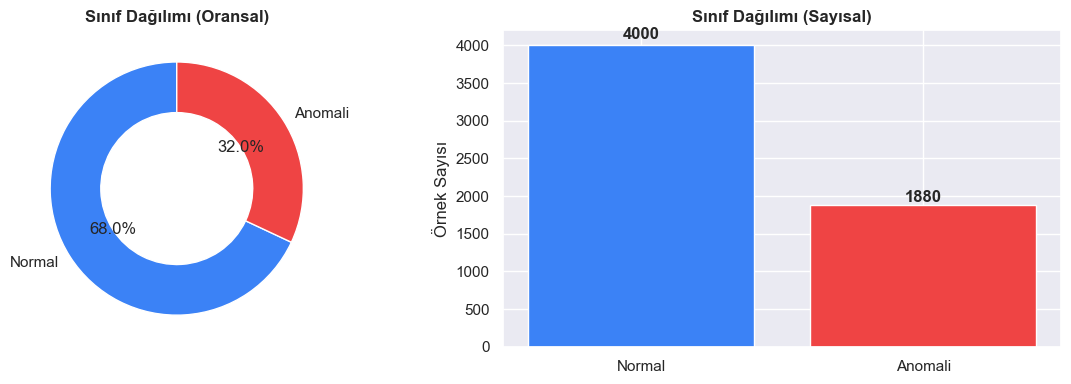

In [4]:
plot_class_distribution_combined(raw_df)
plt.show()

### 2. Hastalık Kategorileri Dağılımı

**Amaç:** Hedef değişken olan anomalinin dışında, veri setindeki farklı hastalık veya hücre kategorilerinin (disease category) alt kırılımlarını anlamaktır.

**Bilimsel Katkısı:** Verideki anormalliklerin hangi spesifik patolojilerden kaynaklandığını görerek modelin genellenebilirliğini (generalization) yorumlamamızı sağlar. Belirli bir hastalık kategorisinin baskın olması durumunda, modelin o alt tipe aşırı uyum (overfitting) sağlayıp sağlamayacağını önceden sezebiliriz.

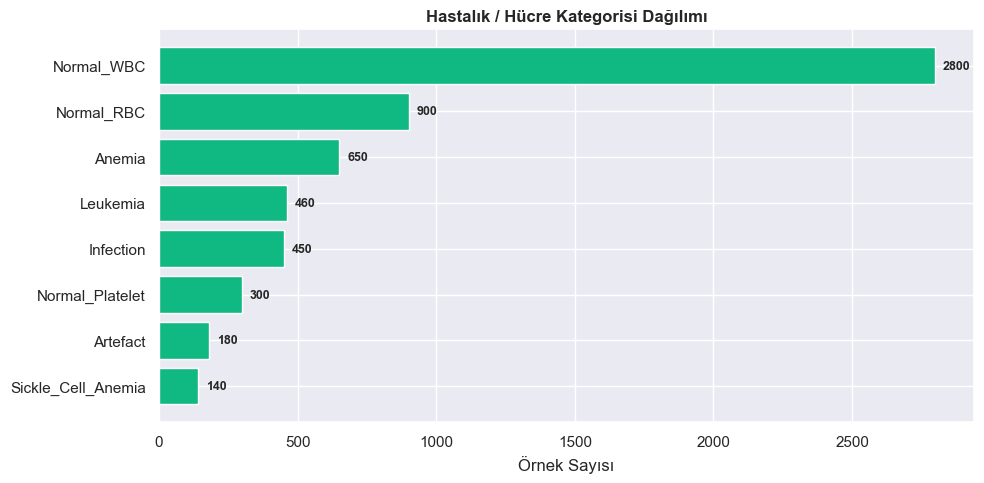

In [5]:
plot_disease_category_distribution(raw_df)
plt.show()

### 3. Korelasyon Isı Haritası (Correlation Heatmap)

**Amaç:** Sayısal değişkenler (özellikler) arasındaki doğrusal veya monotonik ilişkilerin yönünü ve şiddetini ölçmektir.

**Bilimsel Katkısı:** Değişkenler arası çoklu doğrusal bağlantı (multicollinearity) problemini tespit etmemizi sağlar. Birbirleriyle çok yüksek korelasyona sahip olan bağımsız değişkenler, özellikle doğrusal (linear) modellerde katsayıların (weights) güvenilirliğini azaltır ve varyans enflasyonuna (VIF) neden olur. Gerekirse yüksek korelasyonlu değişkenlerin elimine edilmesi için bize rehberlik eder.

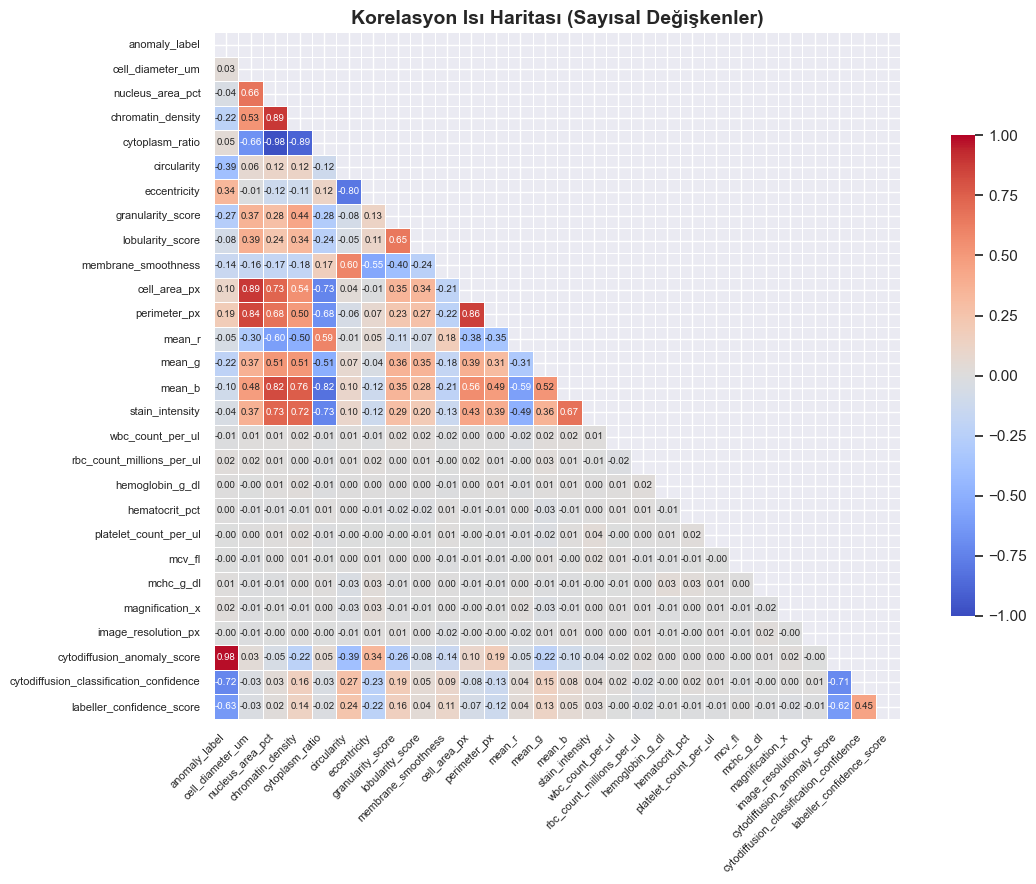

In [6]:
plot_correlation_heatmap(raw_df)
plt.show()

### 4. Özellik Dağılımları (KDE & Boxplot)

**Amaç:** Model için en ayırt edici olan özellikleri bularak (Cohen's d veya istatistiksel testlerle) bu özelliklerin Normal ve Anomali sınıflarındaki dağılımlarını Kernel Density Estimation (KDE) ve Boxplot ile görselleştirmektir.

**Bilimsel Katkısı:** Boxplot grafikleri, değişkenlerin varyansını ve medyan kaymalarını açıkça gösterirken olası aykırı değerleri (outliers) ortaya çıkarır. KDE ise dağılım formunu pürüzsüz bir yoğunluk eğrisi olarak yansıtarak, iki sınıfın ayrılabilirliğini (separability) görsel olarak ispatlar. Eğer bu özelliklerde sınıflar net bir şekilde ayrışıyorsa, makine öğrenmesi modelinin yüksek bir f1-skoru elde etmesi matematiksel olarak beklenir.

KDE ve Boxplot için Seçilen En Önemli Özellikler: ['circularity', 'eccentricity', 'granularity_score', 'chromatin_density']


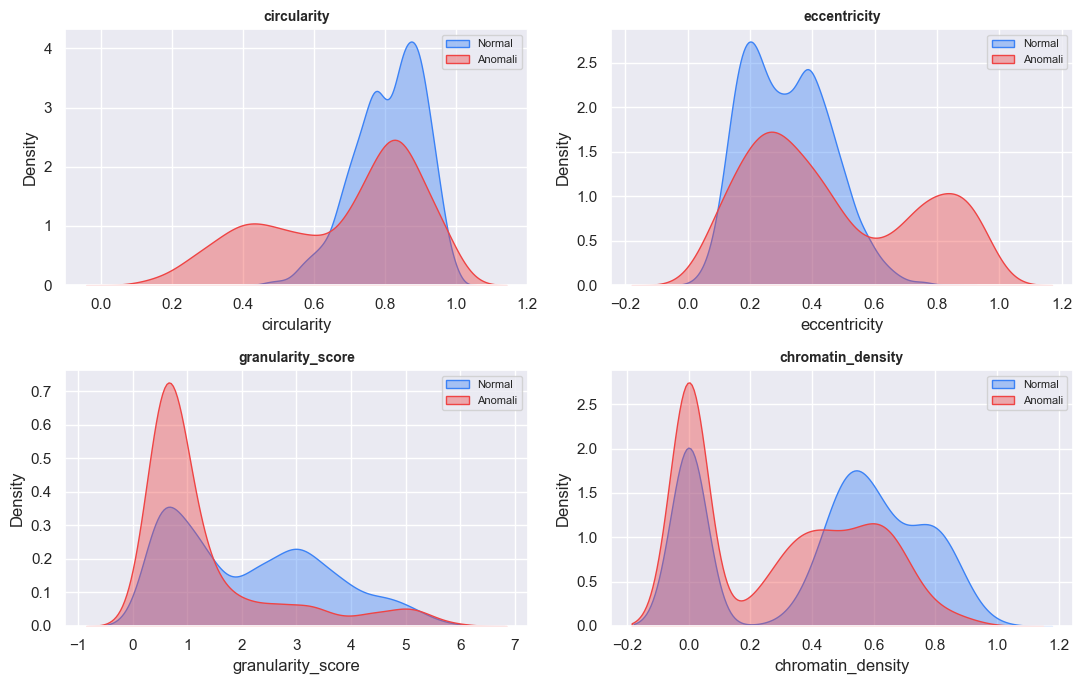

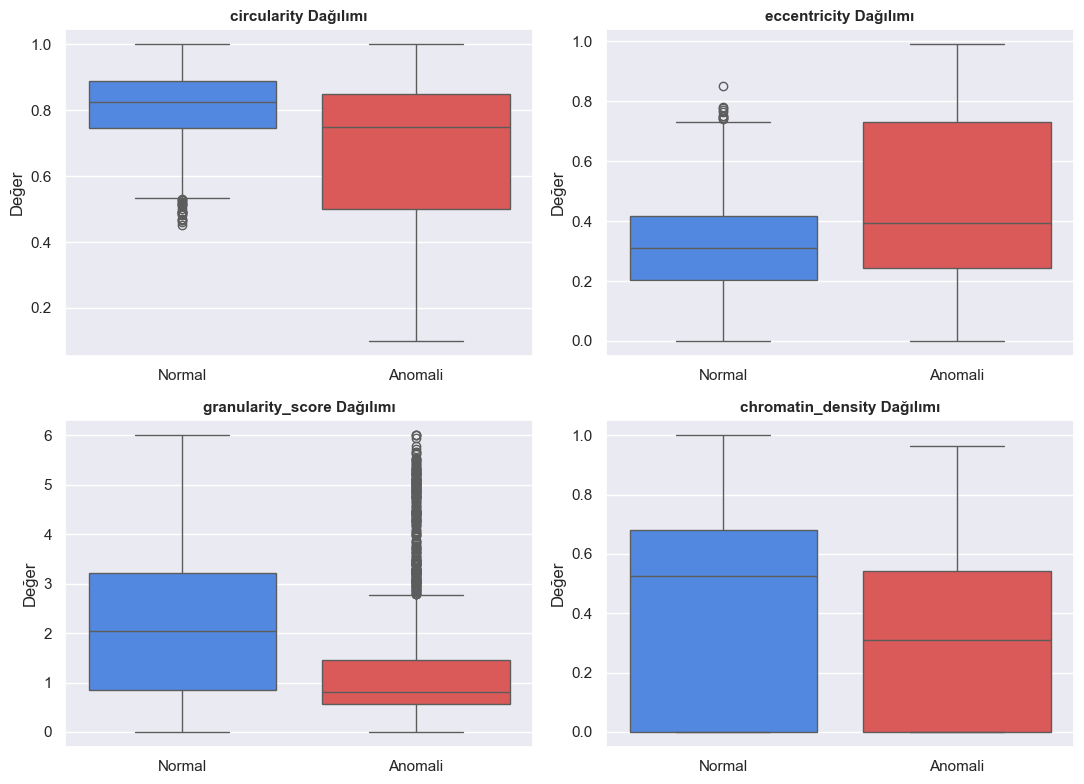

In [7]:
top_features = get_top_features(df_clean, top_n=4)
print(f'KDE ve Boxplot için Seçilen En Önemli Özellikler: {top_features}')

plot_kde_grid(df_clean, top_features)
plt.show()

plot_boxplot_grid(df_clean, top_features)
plt.show()

### 3. Veri Ön İşleme (Preprocessing)

**Neden StratifiedKFold ve StandardScaler Kullanılıyor?**
Veri setimizde hedef değişken ("Normal" vs "Anomali") dengesiz bir dağılıma sahiptir. Veriyi eğitim ve test olarak bölerken `stratify=y` parametresini kullanarak bu dengesiz oranın iki sette de korunmasını sağlıyoruz. Ayrıca, algoritmaların büyük sayılara gereğinden fazla önem vermesini (dominance) engellemek için **StandardScaler** ile özellikleri ortak bir ölçeğe getiriyoruz. Ölçekleyiciyi sadece eğitim verisi üzerinde `fit` ederek gelecekteki verilerin eğitime sızmasını (leakage) önlüyoruz.


In [8]:
def preprocess(df: pd.DataFrame, test_size: float = 0.2, random_state: int = 42):
    """One-Hot + stratified split + StandardScaler (sadece sayısal sütunlar)."""
    y = df[TARGET]
    X = df.drop(columns=[TARGET])

    cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
    num_cols = X.select_dtypes(include=["number"]).columns.tolist()

    X = pd.get_dummies(X, columns=cat_cols, drop_first=True).astype(float)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    scaler = StandardScaler()
    num_present = [c for c in num_cols if c in X_tr.columns]
    X_tr[num_present] = scaler.fit_transform(X_tr[num_present])
    X_te[num_present] = scaler.transform(X_te[num_present])

    return {
        "X_train": X_tr, "X_test": X_te, "y_train": y_tr, "y_test": y_te,
        "scaler": scaler,
        "feature_names": X_tr.columns.tolist(),
        "numerical_cols": num_present,
    }

# Ön İşlemeyi Çalıştırma
pre = preprocess(df_clean, random_state=42)
X_train, X_test, y_train, y_test = pre["X_train"], pre["X_test"], pre["y_train"], pre["y_test"]
print(f"Eğitim Seti Boyutu: {X_train.shape}")
print(f"Test Seti Boyutu: {X_test.shape}")


Eğitim Seti Boyutu: (4704, 33)
Test Seti Boyutu: (1176, 33)


### 4. Modellerin Tanımlanması ve Eğitimi

Ağaç tabanlı üç güçlü model (XGBoost, LightGBM, Random Forest) kullanılarak eğitim gerçekleştirilir. Modellerin ezberlemesini (overfitting) engellemek ve daha güvenilir sonuçlar elde etmek için 5-Fold Cross Validation uygulanır.


In [9]:
def build_model(name: str, random_state: int = 42):
    if name == "XGBoost":
        return XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric="logloss", random_state=random_state,
            verbosity=0, nthread=1,
        )
    if name == "LightGBM":
        return LGBMClassifier(
            n_estimators=300, max_depth=-1, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            random_state=random_state, verbose=-1, n_jobs=1,
        )
    if name == "Random Forest":
        return RandomForestClassifier(
            n_estimators=300, min_samples_split=5, min_samples_leaf=2,
            random_state=random_state, n_jobs=-1,
        )
    raise ValueError(f"Bilinmeyen model: {name}")


def train_with_cv(model, X_train, y_train, X_test, n_folds: int = 5,
                  random_state: int = 42):
    """5-fold StratifiedKFold CV + final fit + test tahmini."""
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv,
                                scoring="f1", n_jobs=1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    return {
        "model": model, "y_pred": y_pred, "y_proba": y_proba,
        "cv_scores": cv_scores,
        "cv_mean": float(cv_scores.mean()),
        "cv_std": float(cv_scores.std()),
    }

train_results = {}
for name in MODEL_NAMES:
    print(f"Eğitiliyor: {name}...")
    model = build_model(name, random_state=42)
    tr = train_with_cv(model, X_train, y_train, X_test, random_state=42)
    train_results[name] = tr
    print(f"  {name} 5-Fold CV F1 Ortalaması: {tr['cv_mean']:.4f}")


Eğitiliyor: XGBoost...
  XGBoost 5-Fold CV F1 Ortalaması: 0.9478
Eğitiliyor: LightGBM...
  LightGBM 5-Fold CV F1 Ortalaması: 0.9535
Eğitiliyor: Random Forest...
  Random Forest 5-Fold CV F1 Ortalaması: 0.9218


### 5. Model Değerlendirmesi ve Performans Karşılaştırma

Eğitilen modeller, hiç görmedikleri test verisi üzerinde değerlendirilir. Sınıflandırma başarısını ölçmek için Confusion Matrix (Karmaşıklık Matrisi), ROC ve Precision-Recall eğrileri çizdirilir.


In [10]:
def evaluate(y_true, y_pred, y_proba=None, cv_mean=None, cv_std=None) -> dict:
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "kappa": cohen_kappa_score(y_true, y_pred),
        "confusion_mat": confusion_matrix(y_true, y_pred),
        "classification_rep": classification_report(
            y_true, y_pred, target_names=["Normal", "Anomali"]
        ),
        "cv_mean": cv_mean, "cv_std": cv_std,
    }
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        out["roc_auc"] = auc(fpr, tpr)
        out["pr_auc"] = average_precision_score(y_true, y_proba)
    return out


def comparison_table(eval_results: dict) -> pd.DataFrame:
    rows = []
    for name, r in eval_results.items():
        rows.append({
            "Model": name,
            "Accuracy": r["accuracy"], "Bal. Acc.": r["balanced_accuracy"],
            "Precision": r["precision"], "Recall": r["recall"],
            "F1-Score": r["f1"], "MCC": r["mcc"], "Kappa": r["kappa"],
            "ROC-AUC": r.get("roc_auc"), "PR-AUC": r.get("pr_auc"),
            "CV Mean (F1)": r.get("cv_mean"),
        })
    return pd.DataFrame(rows).set_index("Model").sort_values("F1-Score", ascending=False)

eval_results = {}
roc_data = {}
pr_data = {}

for name, tr in train_results.items():
    ev = evaluate(y_test, tr["y_pred"], tr["y_proba"], cv_mean=tr["cv_mean"], cv_std=tr["cv_std"])
    eval_results[name] = ev
    
    if tr["y_proba"] is not None:
        fpr, tpr, _ = roc_curve(y_test, tr["y_proba"])
        roc_data[name] = (fpr, tpr, auc(fpr, tpr))
        
        pr_arr, rc_arr, _ = precision_recall_curve(y_test, tr["y_proba"])
        pr_data[name] = (pr_arr, rc_arr, ev.get("pr_auc", 0))

comp_df = comparison_table(eval_results)
best_model_name = comp_df.index[0]
print("Karşılaştırma Tablosu:")
display(comp_df)

print(f"\nEn İyi Model: {best_model_name}")


Karşılaştırma Tablosu:


,Accuracy,Bal. Acc.,Precision,Recall,F1-Score,MCC,Kappa,ROC-AUC,PR-AUC,CV Mean (F1)
Model,,,,,,,,,,
LightGBM,0.982143,0.975598,0.986301,0.957447,0.971660,0.958854,0.958629,0.997719,0.995812,0.953469
XGBoost,0.973639,0.962301,0.985915,0.930851,0.957592,0.939307,0.938491,0.997417,0.995322,0.947779
Random Forest,0.965136,0.947593,0.991202,0.898936,0.942817,0.920093,0.917827,0.996406,0.993900,0.921817



En İyi Model: LightGBM


### Karmaşıklık Matrisi (Confusion Matrix)

**Amaç:** Modelin sınıflandırma hatalarını False Positive (Tip I Hata) ve False Negative (Tip II Hata) olmak üzere granüler boyutta incelemektir.

**Bilimsel Katkısı:** Tıp ve sağlık gibi riskli alanlarda (örneğin kan hücresi anomalisi tespiti) False Negative'in (Hasta olan bir hücreye normal demek) maliyeti, False Positive'e kıyasla çok daha kritiktir. Matris üzerinden modelin hangi yönde hata yaptığını detaylandırarak, Precision (Kesinlik) veya Recall (Duyarlılık) trade-off'u hakkında nihai kararımızı destekliyoruz.

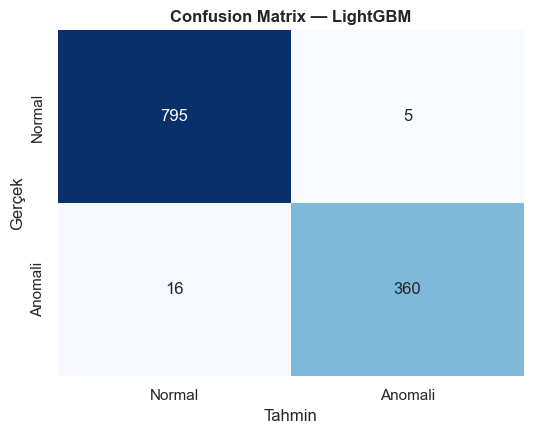

In [11]:
plot_confusion(y_test, train_results[best_model_name]['y_pred'], best_model_name)
plt.show()

### ROC Eğrisi (Receiver Operating Characteristic)

**Amaç:** Modelin ayırt etme (discrimination) gücünü farklı karar eşiklerinde (thresholds) test etmektir.

**Bilimsel Katkısı:** ROC eğrisinin altında kalan alan (AUC - Area Under Curve), modelin rastgele bir anomaliyi normalden daha yüksek bir olasılıkla sıralama becerisini gösterir. AUC'nin 1'e yakın olması modelin sınıfları mükemmel bir şekilde ayırabildiğini kanıtlar; bu, literatürde modellerin birbirleriyle karşılaştırılması için kullanılan evrensel, eşikten bağımsız bir performans metriğidir.

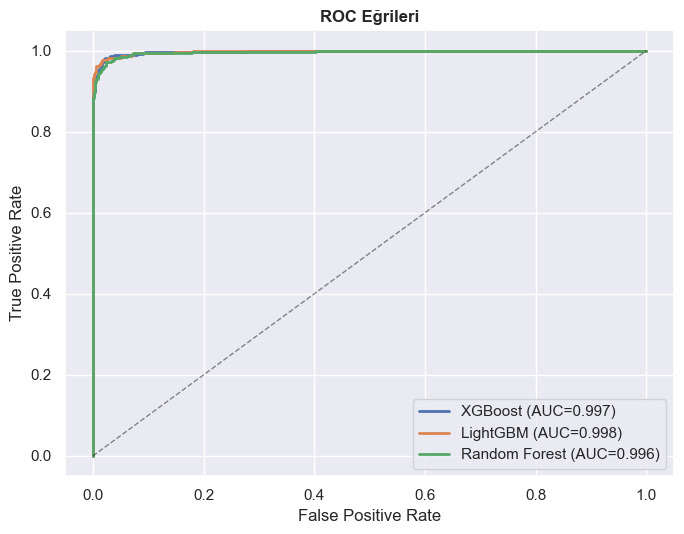

In [12]:
plot_roc(roc_data)
plt.show()

### Precision-Recall (PR) Eğrisi

**Amaç:** Sınıf dengesizliği (class imbalance) durumunda, ROC eğrisinin aşırı iyimser (over-optimistic) sonuçlarını dengelemek için Precision ve Recall metriklerinin değişimini analiz etmektir.

**Bilimsel Katkısı:** Eğer pozitif (Anomali) sınıf azınlıktaysa, True Negative sayısındaki dramatik değişimler ROC'u yanıltabilir. PR Eğrisi doğrudan azınlık sınıftaki performansa odaklandığı için, tıbbi teşhis problemlerinde (minority detection) modelin sahada ne kadar güvenilir çalışacağını ölçmek için ROC'tan çok daha rasyonel bir vekil metrik (proxy) sunar.

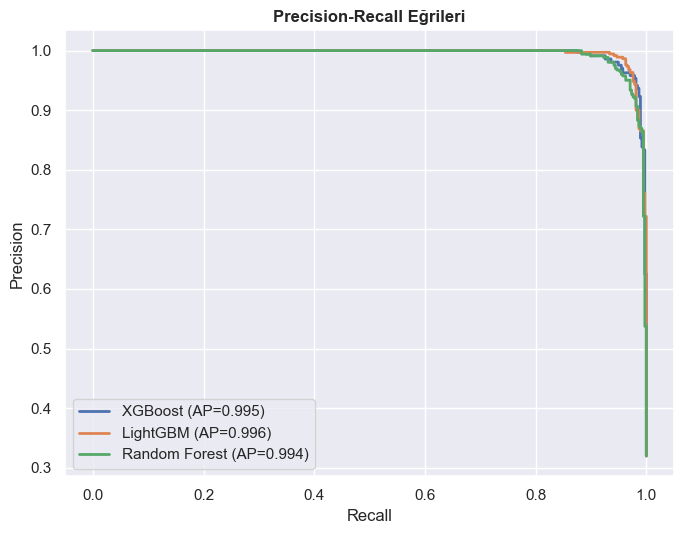

In [13]:
plot_pr(pr_data)
plt.show()

**Değerlendirme ve Tıbbi Metrik Yorumu (False Negative Tehlikesi)**

Sağlık odaklı veri setlerinde "Doğruluk (Accuracy)" yanıltıcı bir metriktir. Asıl önemli olan, gerçekte hasta (anomali) olan bir hücrenin "sağlıklı" sanılarak gözden kaçırılmasıdır. Bu duruma **False Negative (Tip 2 Hata)** denir. False Negative oranının yüksek olması, tedavi edilmesi gereken bir hastanın eve gönderilmesi anlamına gelir ki bu hayati bir risktir.
Bu yüzden projede **Recall (Duyarlılık)** ve **F1-Score** metrikleri optimize edilmiştir. Confusion Matrix'te (Karmaşıklık Matrisi) sol alt köşedeki (FN) sayının olabildiğince sıfıra yakın olması en kritik başarı ölçütüdür.


### 6. Açıklanabilir Yapay Zeka (SHAP Analizi)

Makine öğrenmesi modelinin karar verme sürecini şeffaflaştırmak için SHAP kullanılır. Bu bölümde **Global Özellik Önemi** (modelin tüm veri setindeki genel davranışı) ve **Lokal Açıklama** (tek bir hücre için şelale grafiği ile verilen özel teşhis gerekçesi) incelenmektedir.


In [14]:
def compute_shap(model, X_sample: pd.DataFrame, X_background: pd.DataFrame = None):
    cls_name = type(model).__name__
    tree_models = ("XGBClassifier", "LGBMClassifier", "RandomForestClassifier")
    if cls_name in tree_models:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)
    else:
        bg = X_background if X_background is not None else X_sample.head(50)
        explainer = shap.KernelExplainer(model.predict_proba, bg)
        shap_values = explainer.shap_values(X_sample, silent=True)

    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    elif shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]

    base = explainer.expected_value
    if isinstance(base, (list, np.ndarray)):
        base = float(np.array(base).flatten()[-1])

    return {
        "shap_values": shap_values,
        "base_value": float(base),
        "X_sample": X_sample,
        "feature_names": list(X_sample.columns),
    }


def plot_shap_bar(result: dict, top_n: int = 15):
    mean_abs = np.abs(result["shap_values"]).mean(axis=0)
    s = pd.Series(mean_abs, index=result["feature_names"]).sort_values().tail(top_n)
    fig, ax = plt.subplots(figsize=(8, max(4, len(s) * 0.35)))
    ax.barh(s.index, s.values, color="#f59e0b")
    ax.set_xlabel("Ortalama |SHAP|")
    ax.set_title(f"Global Özellik Önemi — SHAP (Top {top_n})", weight="bold")
    plt.tight_layout()
    return fig


def plot_shap_summary(result: dict, top_n: int = 15):
    plt.figure(figsize=(9, max(5, top_n * 0.4)))
    shap.summary_plot(result["shap_values"], result["X_sample"],
                      max_display=top_n, show=False)
    return plt.gcf()


def plot_shap_waterfall(result: dict, idx: int, top_n: int = 12):
    shap_row = result["shap_values"][idx]
    x_row = result["X_sample"].iloc[idx]
    order = np.argsort(np.abs(shap_row))[-top_n:]
    feats = [result["feature_names"][i] for i in order]
    vals = shap_row[order]
    feat_vals = x_row.values[order]

    fig, ax = plt.subplots(figsize=(9, max(4, top_n * 0.45)))
    colors = ["#ef4444" if v > 0 else "#3b82f6" for v in vals]
    ax.barh(range(len(feats)), vals, color=colors)
    ax.set_yticks(range(len(feats)))
    ax.set_yticklabels([f"{f} = {v:.3f}" for f, v in zip(feats, feat_vals)],
                       fontsize=9)
    ax.axvline(0, color="black", lw=0.5)
    total = shap_row.sum()
    ax.set_title(
        f"Lokal Açıklama #{idx} — base={result['base_value']:+.3f}, "
        f"toplam SHAP={total:+.3f}", weight="bold"
    )
    ax.set_xlabel("SHAP değeri")
    plt.tight_layout()
    return fig

best_model = train_results[best_model_name]["model"]
X_sample = X_test.head(200)

print("SHAP Değerleri Hesaplanıyor...")
shap_res = compute_shap(best_model, X_sample, X_train.head(100))

SHAP Değerleri Hesaplanıyor...


### SHAP (Açıklanabilir YZ) - Global Özellik Önemi (Beeswarm Plot)

**Amaç:** Modelin 'Black-Box' (kapalı kutu) doğasını kırıp, hangi veri özelliklerinin model tahminini evrensel (global) çapta en çok etkilediğini görmektir.

**Bilimsel Katkısı:** Ağaç tabanlı modellerin (örn. Random Forest, XGBoost) standart feature importance (Gini/Gain) değerleri sadece kural bölme sayısına dayanır ve yön belirtmez. SHAP, oyun teorisi (Shapley Values) kullanarak her bir özelliğin marjinal katkısını *pozitif* veya *negatif* yönlü ve matematiksel bir tutarlılıkla hesaplar. Böylece model kararlarının mantıklı (domain uzmanlığı ile örtüşen) paternler öğrenip öğrenmediği şeffaflaştırılır.

In [ ]:
print('\n1. Global Özellik Önemi (Bar Chart)')
plot_shap_bar(shap_res, top_n=12)
plt.show()

print('\n2. Global Özellik Önemi (Beeswarm Plot)')
plot_shap_summary(shap_res, top_n=12)
plt.show()

### SHAP Waterfall Grafikleri - Örnek Vaka (Lokal) Analizleri

**Amaç:** Modelin global performansından ziyade, bireysel ve spesifik hücre örnekleri üzerinde neden 'Normal' veya 'Anomali' dediğini deşifre etmektir.

**Bilimsel Katkısı:** Gerçek dünyada bir hekimin 'Sistem bu hücreye neden anomali dedi?' sorusuna verilecek en somut cevaptır. Waterfall grafiği, base_value'dan (beklenen ortalama tahmin) başlayarak o anki hücrenin özellik değerlerinin modeli nasıl itip çektiğini gösterir. Doğru pozitif (TP), doğru negatif (TN) ve hatalı kararları (FP/FN) detaylı analiz ederek sistemin kör noktalarını ve güvenilirliğini tespit etmiş oluruz.

In [ ]:
print('\n3. Örnek Vaka Analizleri (Lokal Açıklama - Waterfall Plots)')

y_arr = y_test.reset_index(drop=True)
preds = best_model.predict(X_sample)

tp_idx, tn_idx, err_idx = None, None, None
for i in range(len(X_sample)):
    actual = int(y_arr.iloc[i])
    pred = int(preds[i])
    if actual == 1 and pred == 1 and tp_idx is None: tp_idx = i
    elif actual == 0 and pred == 0 and tn_idx is None: tn_idx = i
    elif actual != pred and err_idx is None: err_idx = i
    if tp_idx is not None and tn_idx is not None and err_idx is not None: break

cases = [(tp_idx, 'Vaka 1: Başarılı Anomali Tespiti (True Positive)'),
         (tn_idx, 'Vaka 2: Başarılı Normal Hücre Tespiti (True Negative)'),
         (err_idx, 'Vaka 3: Model Yanılgısı (Hata Analizi - FP/FN)')]

for idx, title in cases:
    if idx is not None:
        print(f'\n--- {title} ---')
        actual = int(y_arr.iloc[idx])
        pred = int(preds[idx])
        actual_label = 'Anomali' if actual == 1 else 'Normal'
        pred_label = 'Anomali' if pred == 1 else 'Normal'
        print(f'Gerçek Sınıf: {actual_label} | Modelin Tahmini: {pred_label}')
        plot_shap_waterfall(shap_res, idx, top_n=10)
        plt.show()


**SHAP Metrikleri Yorumu**

*   **Global Özellik Önemi (Beeswarm Grafiği):** Bu grafik, modelin genel kanısında hangi özelliklerin en baskın rol oynadığını gösterir. Kırmızı noktalar o özelliğin yüksek değerini, mavi noktalar düşük değerini temsil eder. Örneğin bir noktanın sağa (pozitif SHAP değerine) gitmesi, o özelliğin modeli "Anomali" kararına ittiği anlamına gelir.
*   **Lokal Açıklama (Waterfall - Şelale Grafiği):** Bu grafik sadece belirli bir hasta (veya hücre) için çalışır. Taban değerden (base value) başlayarak, o spesifik hücrenin sahip olduğu kan değerlerinin (örneğin hücre çapının geniş olması) sonucu nasıl yukarı (anomali) veya aşağı (normal) çektiğini adım adım gösterir. Tıbbi bir teşhisin sağlamasını yapmak için doktorlara sunulacak en kritik analizdir.
